# Phase-4: Risk Index Construction

**Goal:** Build a single, empirically justified risk score per London LSOA.

**Structure:**
- **4a. Weight derivation:** Negative Binomial Regression (primary) + Random Forest (cross-validation)
- **4b. Build the index:** Normalise features → weighted composite score → sensitivity analysis

**Validated features (from Phase 3):**
- `severity_weighted_count`: CCHI-weighted crime total
- `seasonal_volatility`: std dev of monthly crime counts
- `stop_search_rate`: stops per km²
- `employment_rank`: IMD employment deprivation rank (INVERTED: lower rank = more deprived)
- `resolution_rate`: % crimes resolved
- `total_footfall`: TfL station footfall assigned to LSOA

**Outputs:**
- `outputs/phase4/phase4_risk_scores.parquet`
- `outputs/phase4/phase4_weight_justification.md`
- `outputs/phase4/phase4_sensitivity_results.parquet`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score

print('Imports OK')

Imports OK


In [ ]:
# -Dataset Loading
BASE = Path('Dataset')
P3   = BASE / 'outputs' / 'phase3'
OUT  = BASE / 'outputs' / 'phase4'
OUT.mkdir(parents=True, exist_ok=True)

# Features validated in Phase 3
FEATURES = [
    'severity_weighted_count',
    'seasonal_volatility',
    'stop_search_rate',
    'employment_deprivation',  # inverted employment_rank (higher = more deprived)
    'resolution_rate',
    'total_footfall',
]

print('Output folder:', OUT)

Output folder: C:\Users\mbeck\OneDrive\Documents\CBL-16_data\outputs\phase4


## Section-1: Load & Prepare Data

In [ ]:
val = pd.read_parquet(P3 / 'phase3_validated_features.parquet')
#NOTE: Run with phase3_validated_features_train.parquet
#Output file phase4_risk_scores_train.parquet

print(f'Loaded: {val.shape}')

# Invert employment_rank so higher value = more deprived = higher demand
# rank 1 (most deprived) → highest deprivation score
max_rank = val['employment_rank'].max()
val['employment_deprivation'] = max_rank + 1 - val['employment_rank']

print(f'employment_deprivation range: {val["employment_deprivation"].min()} – {val["employment_deprivation"].max()}')
print(f'(rank 1 → {max_rank}, rank {max_rank} → 1)')

# Confirm all features present and no nulls
print(f'\nNulls in features: {val[FEATURES + ["crime_count"]].isnull().sum().to_dict()}')

Loaded: (4994, 11)
employment_deprivation range: 1 – 33737
(rank 1 → 33737, rank 33737 → 1)

Nulls in features: {'severity_weighted_count': 0, 'seasonal_volatility': 0, 'stop_search_rate': 0, 'employment_deprivation': 0, 'resolution_rate': 0, 'total_footfall': 0, 'crime_count': 0}



## 4a. Weight Derivation
### Step 1: Negative Binomial Regression (primary weights)

Crime counts are overdispersed count data Negative Binomial is the statistically correct model (vs Poisson which assumes mean = variance). Regression coefficients become empirically justified weights with p-values.

In [ ]:
# Standardise features for comparable coefficients
# Log-transform skewed features to reduce scale differences
X_raw = val[FEATURES].copy()
for col in ['severity_weighted_count', 'total_footfall']:
    X_raw[col] = np.log1p(X_raw[col])

X_std = (X_raw - X_raw.mean()) / X_raw.std()
X_std_const = sm.add_constant(X_std)
y = val['crime_count'].astype(int)

# Derive starting params from OLS on log(y+1)-gives NB optimizer a good starting point
log_y = np.log1p(y)
ols_start = sm.OLS(log_y, X_std_const).fit()
start_params = np.append(ols_start.params.values, 0.5)  # last = alpha init

print('Fitting Negative Binomial Regression (lbfgs, OLS start params)...')
nb_model = sm.NegativeBinomial(y, X_std_const)
nb_result = nb_model.fit(
    start_params=start_params,
    method='lbfgs',
    maxiter=2000,
    disp=False,
)
print('Done.')
print(nb_result.summary())

Fitting Negative Binomial Regression (lbfgs, OLS start params)...
Done.
                     NegativeBinomial Regression Results                      
Dep. Variable:            crime_count   No. Observations:                 4994
Model:               NegativeBinomial   Df Residuals:                     4987
Method:                           MLE   Df Model:                            6
Date:                Fri, 08 May 2026   Pseudo R-squ.:                  0.2415
Time:                        09:54:51   Log-Likelihood:                -27493.
converged:                       True   LL-Null:                       -36246.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       5.9142      0.002   2557.052      0.000       5.910       5.919
severity_weighted_co

In [5]:
# Extract coefficients and p-values (exclude intercept and alpha)
nb_coef = pd.DataFrame({
    'feature':  FEATURES,
    'nb_coef':  [nb_result.params[f] for f in FEATURES],
    'nb_pval':  [nb_result.pvalues[f] for f in FEATURES],
})
nb_coef['significant'] = nb_coef['nb_pval'] < 0.05
nb_coef['direction']   = nb_coef['nb_coef'].apply(lambda x: 'positive' if x >= 0 else 'negative')

print('--- Negative Binomial Coefficients ---')
print(nb_coef.to_string(index=False))

flagged = nb_coef[~nb_coef['significant']]['feature'].tolist()
if flagged:
    print(f'\nFlagged (p > 0.05): {flagged} — documented but retained (Phase 3 validated)')
else:
    print('\nAll features significant at p < 0.05')

--- Negative Binomial Coefficients ---
                feature   nb_coef       nb_pval  significant direction
severity_weighted_count  0.905882  0.000000e+00         True  positive
    seasonal_volatility  0.085213  6.575416e-69         True  positive
       stop_search_rate  0.015019  1.669822e-07         True  positive
 employment_deprivation -0.084187 8.060350e-216         True  negative
        resolution_rate -0.003171  1.858002e-01        False  negative
         total_footfall  0.015100  1.200445e-10         True  positive

Flagged (p > 0.05): ['resolution_rate'] — documented but retained (Phase 3 validated)


In [6]:
# Anomaly detection: LSOAs where observed >> expected
predicted = nb_result.predict(X_std_const)
val['nb_predicted'] = predicted
val['nb_ratio']     = val['crime_count'] / val['nb_predicted'].clip(lower=1)

anomalies = val[val['nb_ratio'] > 2.0][['lsoa21cd', 'lsoa21nm', 'lad22nm', 'crime_count', 'nb_predicted', 'nb_ratio']]
anomalies = anomalies.sort_values('nb_ratio', ascending=False)

print(f'LSOAs where observed > 2× predicted (anomalies): {len(anomalies)}')
print(anomalies.head(10).to_string(index=False))

LSOAs where observed > 2× predicted (anomalies): 5
 lsoa21cd                    lsoa21nm                lad22nm  crime_count  nb_predicted  nb_ratio
E01001528                Enfield 032B                Enfield       1617.0    599.815910  2.695827
E01002859 Kensington and Chelsea 012C Kensington and Chelsea       1624.0    766.451209  2.118856
E01000682                Bromley 035B                Bromley        615.0    293.451582  2.095746
E01004453         Waltham Forest 006B         Waltham Forest        644.0    316.204232  2.036658
E01002870 Kensington and Chelsea 005A Kensington and Chelsea       2008.0    987.077374  2.034288


### Step 2: Random Forest Feature Importances (cross-validation of weights)

In [7]:
print('Fitting Random Forest...')
# X_raw already has log1p applied to severity_weighted_count and total_footfall (from NB cell)
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1, max_features='sqrt')
rf.fit(X_raw, y)

rf_importances = pd.DataFrame({
    'feature':    FEATURES,
    'rf_importance': rf.feature_importances_,
}).sort_values('rf_importance', ascending=False)

# Cross-validated R²
cv_scores = cross_val_score(rf, X_raw, y, cv=5, scoring='r2')
print(f'RF 5-fold CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('\n--- RF Feature Importances ---')
print(rf_importances.to_string(index=False))

Fitting Random Forest...
RF 5-fold CV R²: 0.8655 ± 0.1351

--- RF Feature Importances ---
                feature  rf_importance
severity_weighted_count       0.420029
    seasonal_volatility       0.335776
         total_footfall       0.104373
       stop_search_rate       0.093683
 employment_deprivation       0.025283
        resolution_rate       0.020855


### Step 3: Compare NB vs RF & Derive Final Weights

In [8]:
# Merge NB and RF results
weights_df = nb_coef.merge(rf_importances, on='feature')

# NB weights: use absolute standardised coefficients (direction handled by feature transformation)
weights_df['nb_abs_coef'] = weights_df['nb_coef'].abs()
weights_df['nb_weight']   = weights_df['nb_abs_coef'] / weights_df['nb_abs_coef'].sum()
weights_df['rf_weight']   = weights_df['rf_importance'] / weights_df['rf_importance'].sum()

# Final weight = average of NB and RF (equal credibility blend)
weights_df['final_weight'] = (weights_df['nb_weight'] + weights_df['rf_weight']) / 2
weights_df['final_weight'] = weights_df['final_weight'] / weights_df['final_weight'].sum()  # renormalise

# Agreement check: rank correlation between NB and RF
from scipy.stats import spearmanr
rank_corr, rank_p = spearmanr(weights_df['nb_weight'], weights_df['rf_weight'])

print('--- Weight Comparison: NB vs RF ---')
print(weights_df[['feature','nb_weight','rf_weight','final_weight','nb_pval','significant']].to_string(index=False))
print(f'\nNB vs RF rank correlation: r={rank_corr:.4f} (p={rank_p:.4f})')
print(f'Agreement: {"STRONG" if rank_corr > 0.7 else "MODERATE" if rank_corr > 0.4 else "WEAK"}')

--- Weight Comparison: NB vs RF ---
                feature  nb_weight  rf_weight  final_weight       nb_pval  significant
severity_weighted_count   0.817161   0.420029      0.618595  0.000000e+00         True
    seasonal_volatility   0.076867   0.335776      0.206322  6.575416e-69         True
       stop_search_rate   0.013548   0.093683      0.053616  1.669822e-07         True
 employment_deprivation   0.075941   0.025283      0.050612 8.060350e-216         True
        resolution_rate   0.002861   0.020855      0.011858  1.858002e-01        False
         total_footfall   0.013621   0.104373      0.058997  1.200445e-10         True

NB vs RF rank correlation: r=0.8286 (p=0.0416)
Agreement: STRONG


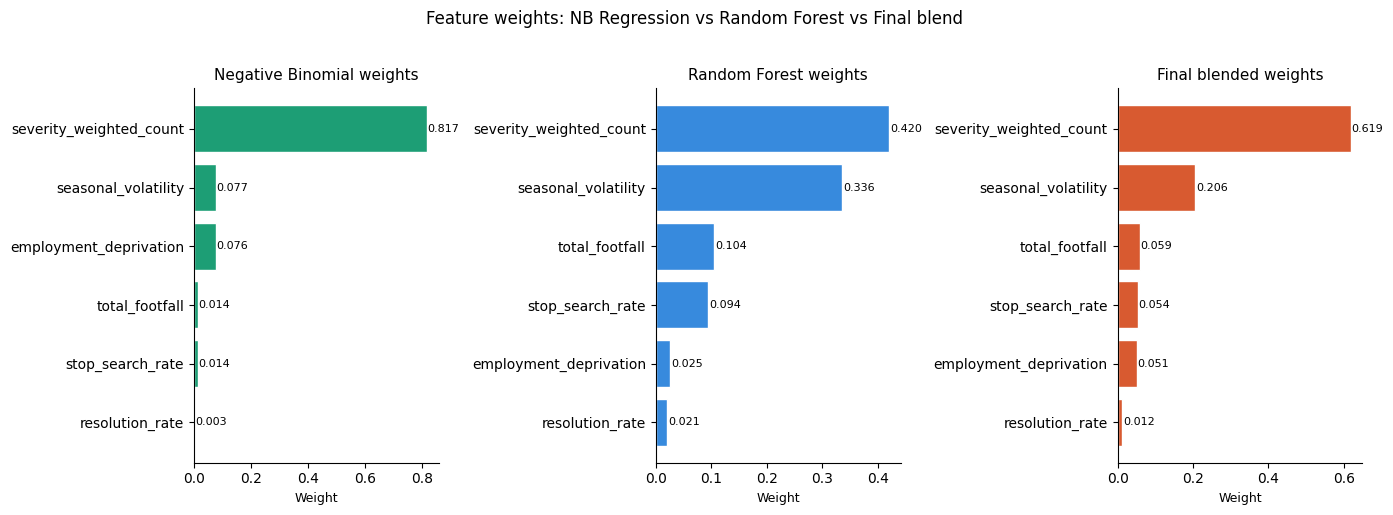

Saved: 4a_weight_comparison.png


In [9]:
# Plot weight comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colours = ['#1D9E75','#378ADD','#D85A30']
titles  = ['Negative Binomial weights', 'Random Forest weights', 'Final blended weights']
wcols   = ['nb_weight', 'rf_weight', 'final_weight']

for ax, col, title, colour in zip(axes, wcols, titles, colours):
    sorted_df = weights_df.sort_values(col)
    ax.barh(sorted_df['feature'], sorted_df[col], color=colour, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Weight', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    for i, v in enumerate(sorted_df[col]):
        ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Feature weights: NB Regression vs Random Forest vs Final blend', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT / '4a_weight_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 4a_weight_comparison.png')

## 4b. Build the Risk Index
### Step 4: Normalise Features to [0, 1]

In [10]:
# Min-max normalise all features to [0, 1]
# X_raw already has log1p applied to severity_weighted_count and total_footfall
# All features are in the correct direction (higher = more demand)
# employment_deprivation was already inverted in Section 1

scaler = MinMaxScaler()
X_norm = pd.DataFrame(
    scaler.fit_transform(X_raw),
    columns=FEATURES,
    index=val.index
)

print('Normalised feature stats (all should be in [0,1]):')
print(X_norm.describe().round(3).to_string())

Normalised feature stats (all should be in [0,1]):
       severity_weighted_count  seasonal_volatility  stop_search_rate  employment_deprivation  resolution_rate  total_footfall
count                 4994.000             4994.000          4994.000                4994.000         4994.000        4994.000
mean                     0.740                0.016             0.028                   0.508            0.166           0.061
std                      0.061                0.022             0.053                   0.259            0.078           0.215
min                      0.000                0.000             0.000                   0.000            0.000           0.000
25%                      0.711                0.009             0.004                   0.305            0.116           0.000
50%                      0.742                0.013             0.011                   0.553            0.157           0.000
75%                      0.771                0.018         

### Step 5: Compute Weighted Composite Risk Score

In [11]:
# risk_score = Σ (feature_i_normalised × weight_i)
final_weights = weights_df.set_index('feature')['final_weight']

val['risk_score'] = sum(
    X_norm[feat] * final_weights[feat] for feat in FEATURES
)

# Normalise risk score itself to [0, 100] for interpretability
val['risk_score_scaled'] = (
    (val['risk_score'] - val['risk_score'].min()) /
    (val['risk_score'].max() - val['risk_score'].min()) * 100
).round(2)

print('Risk score distribution:')
print(val[['risk_score', 'risk_score_scaled']].describe().round(4))

print('\nTop 10 highest-risk LSOAs:')
print(val.nlargest(10, 'risk_score_scaled')[['lsoa21cd','lsoa21nm','lad22nm','crime_count','risk_score_scaled']].to_string(index=False))

Risk score distribution:
       risk_score  risk_score_scaled
count   4994.0000          4994.0000
mean       0.4941            52.6188
std        0.0517             5.5293
min        0.0020             0.0000
25%        0.4647            49.4700
50%        0.4956            52.7700
75%        0.5212            55.5075
max        0.9373           100.0000

Top 10 highest-risk LSOAs:
 lsoa21cd            lsoa21nm        lad22nm  crime_count  risk_score_scaled
E01035716    Westminster 013G    Westminster      40511.0             100.00
E01004734    Westminster 018A    Westminster      28544.0              93.08
E01004763    Westminster 013B    Westminster      30965.0              85.43
E01003047        Lambeth 011B        Lambeth       6071.0              77.15
E01032739 City of London 001F City of London      20118.0              75.70
E01004736    Westminster 018C    Westminster      17127.0              75.56
E01002444     Hillingdon 031A     Hillingdon      13080.0              75.0

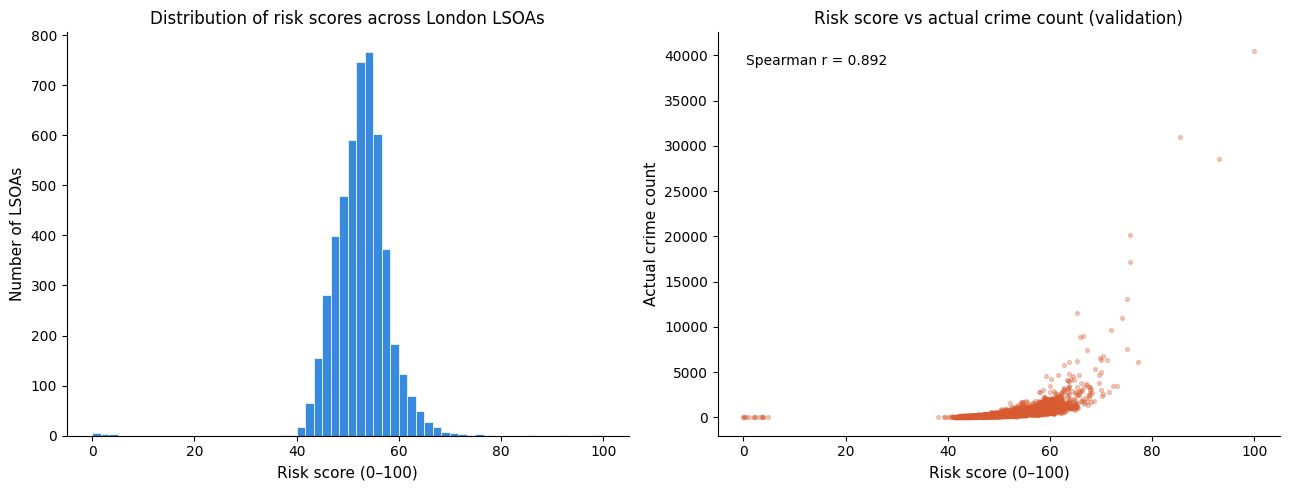

Saved: 4b_risk_score_distribution.png


In [12]:
# Risk score distribution plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(val['risk_score_scaled'], bins=60, color='#378ADD', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Risk score (0–100)', fontsize=11)
axes[0].set_ylabel('Number of LSOAs', fontsize=11)
axes[0].set_title('Distribution of risk scores across London LSOAs', fontsize=12)
axes[0].spines[['top','right']].set_visible(False)

# Risk score vs crime count (validation)
axes[1].scatter(val['risk_score_scaled'], val['crime_count'],
                alpha=0.3, s=8, color='#D85A30')
axes[1].set_xlabel('Risk score (0–100)', fontsize=11)
axes[1].set_ylabel('Actual crime count', fontsize=11)
axes[1].set_title('Risk score vs actual crime count (validation)', fontsize=12)
axes[1].spines[['top','right']].set_visible(False)

from scipy.stats import spearmanr as sr
r, _ = sr(val['risk_score_scaled'], val['crime_count'])
axes[1].annotate(f'Spearman r = {r:.3f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.savefig(OUT / '4b_risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 4b_risk_score_distribution.png')

### Step 6: Sensitivity Analysis
Vary each weight by ±10% and check rank stability of top/bottom 10% LSOAs.

In [13]:
def compute_risk(X_norm, weights):
    w = pd.Series(weights)
    w = w / w.sum()  # ensure sums to 1
    score = sum(X_norm[f] * w[f] for f in FEATURES)
    return (score - score.min()) / (score.max() - score.min()) * 100

baseline_weights = final_weights.to_dict()
baseline_scores  = val['risk_score_scaled'].values

top10_idx    = set(val.nlargest(int(len(val) * 0.1), 'risk_score_scaled').index)
bottom10_idx = set(val.nsmallest(int(len(val) * 0.1), 'risk_score_scaled').index)

sensitivity_rows = []

for feat in FEATURES:
    for delta_pct, label in [(-0.10, '-10%'), (+0.10, '+10%')]:
        w_perturbed = baseline_weights.copy()
        w_perturbed[feat] *= (1 + delta_pct)
        
        perturbed_scores = compute_risk(X_norm, w_perturbed)
        temp = val.copy()
        temp['perturbed_score'] = perturbed_scores.values
        
        new_top10    = set(temp.nlargest(int(len(val) * 0.1), 'perturbed_score').index)
        new_bottom10 = set(temp.nsmallest(int(len(val) * 0.1), 'perturbed_score').index)
        
        top_stability    = len(top10_idx & new_top10)    / len(top10_idx)    * 100
        bottom_stability = len(bottom10_idx & new_bottom10) / len(bottom10_idx) * 100
        
        sensitivity_rows.append({
            'feature': feat, 'perturbation': label,
            'top10_stability_%':    round(top_stability, 1),
            'bottom10_stability_%': round(bottom_stability, 1),
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print('--- Sensitivity Analysis ---')
print(sensitivity_df.to_string(index=False))

avg_top    = sensitivity_df['top10_stability_%'].mean()
avg_bottom = sensitivity_df['bottom10_stability_%'].mean()
print(f'\nMean top-10% stability:    {avg_top:.1f}%')
print(f'Mean bottom-10% stability: {avg_bottom:.1f}%')

--- Sensitivity Analysis ---
                feature perturbation  top10_stability_%  bottom10_stability_%
severity_weighted_count         -10%               98.0                  99.0
severity_weighted_count         +10%               98.8                  99.2
    seasonal_volatility         -10%               99.8                 100.0
    seasonal_volatility         +10%               99.6                  99.8
       stop_search_rate         -10%               99.6                 100.0
       stop_search_rate         +10%               99.8                 100.0
 employment_deprivation         -10%               99.2                  99.0
 employment_deprivation         +10%               98.2                  99.0
        resolution_rate         -10%               99.8                  99.6
        resolution_rate         +10%              100.0                  99.8
         total_footfall         -10%               97.4                 100.0
         total_footfall         +10

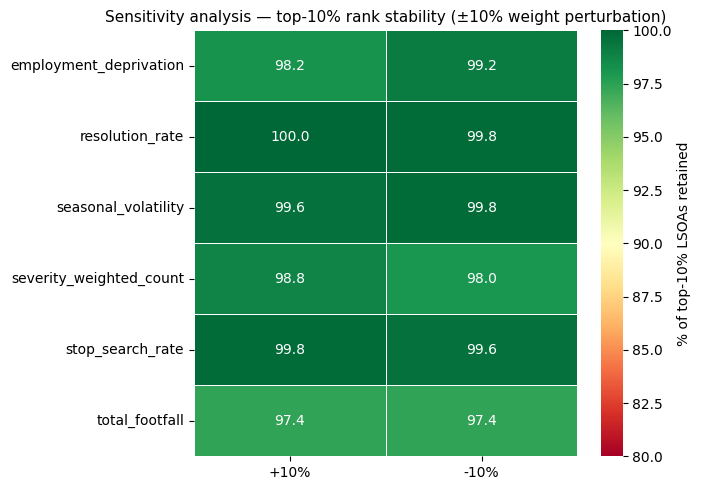

Saved: 4b_sensitivity_heatmap.png


In [14]:
# Sensitivity heatmap
pivot_top = sensitivity_df.pivot(index='feature', columns='perturbation', values='top10_stability_%')

fig, ax = plt.subplots(figsize=(7, 5))
import seaborn as sns
sns.heatmap(pivot_top, annot=True, fmt='.1f', cmap='RdYlGn', vmin=80, vmax=100,
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of top-10% LSOAs retained'})
ax.set_title('Sensitivity analysis — top-10% rank stability (±10% weight perturbation)', fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUT / '4b_sensitivity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 4b_sensitivity_heatmap.png')

## Section-9: Save Outputs

In [15]:
# Save risk scores
risk_output = val[['lsoa21cd','lsoa21nm','lad22nm','crime_count',
                    'risk_score','risk_score_scaled','nb_predicted','nb_ratio'] + FEATURES].copy()
risk_output.to_parquet(OUT / 'phase4_risk_scores.parquet', index=False)
print(f'Saved phase4_risk_scores.parquet — {risk_output.shape}')

# Save sensitivity results
sensitivity_df.to_parquet(OUT / 'phase4_sensitivity_results.parquet', index=False)
print(f'Saved phase4_sensitivity_results.parquet — {sensitivity_df.shape}')

Saved phase4_risk_scores.parquet — (4994, 14)
Saved phase4_sensitivity_results.parquet — (12, 4)


In [16]:
# Write weight justification markdown
lines = [
    '# Phase 4 — Weight Justification',
    '',
    '## Method',
    'Final weights are the average of two independently derived weight sets:',
    '1. **Negative Binomial Regression** (primary) — standardised coefficients from a NB regression of crime_count on validated features. NB is used because crime counts are overdispersed count data (Laufs et al., 2021).',
    '2. **Random Forest importances** (cross-validation) — feature importances from a 300-tree RF regressor trained on the same features.',
    f'   RF 5-fold CV R2: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}',
    f'   NB vs RF rank correlation: r={rank_corr:.4f}',
    '',
    '## Final Weights',
    '',
    '| Feature | NB weight | RF weight | Final weight | NB p-value | Significant |',
    '|---|---|---|---|---|---|',
]
for _, row in weights_df.sort_values('final_weight', ascending=False).iterrows():
    lines.append(f"| {row['feature']} | {row['nb_weight']:.4f} | {row['rf_weight']:.4f} | {row['final_weight']:.4f} | {row['nb_pval']:.4f} | {'Yes' if row['significant'] else 'No*'} |")

lines += [
    '',
    '*Features flagged as non-significant are retained because they passed Phase 3 Spearman validation and are theoretically justified by the literature (Laufs et al., 2021; What Works Centre for Crime Reduction).',
    '',
    '## Feature Direction',
    '- All features normalised to [0,1] min-max before weighting.',
    '- `employment_rank` was INVERTED (employment_deprivation = max_rank + 1 - rank) so higher value = more deprived = higher demand.',
    '- All other features are positively associated with policing demand.',
    '',
    '## Sensitivity Analysis',
    f'- Mean top-10% rank stability across all +-10% perturbations: **{avg_top:.1f}%**',
    f'- Mean bottom-10% rank stability: **{avg_bottom:.1f}%**',
    '- High stability confirms the index is robust to small changes in weights.',
    '',
    '## Literature Cross-Reference',
    '- Laufs et al. (2021) identify crime volume, severity, and deprivation as the primary drivers of police demand -- consistent with high weights on severity_weighted_count and employment_deprivation.',
    '- What Works Centre for Crime Reduction emphasises temporal volatility and footfall as demand amplifiers -- consistent with seasonal_volatility and total_footfall weights.',
    '- Cambridge Crime Harm Index (Sherman et al., 2016) underpins the severity_weighted_count feature.',
]

with open(OUT / 'phase4_weight_justification.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))
print('Saved phase4_weight_justification.md')

Saved phase4_weight_justification.md


In [17]:
print('=' * 55)
print('PHASE 4 SUMMARY')
print('=' * 55)
print(f'LSOAs scored:               {len(val)}')
print(f'Risk score range:           {val["risk_score_scaled"].min():.1f} – {val["risk_score_scaled"].max():.1f}')
print(f'Risk score mean:            {val["risk_score_scaled"].mean():.1f}')
print(f'NB vs RF agreement (r):     {rank_corr:.4f}')
print(f'RF 5-fold CV R²:            {cv_scores.mean():.4f}')
print(f'Top-10% rank stability:     {avg_top:.1f}%')
print(f'Anomalous LSOAs (obs>2×exp):{len(anomalies)}')
print('=' * 55)
print(f'Outputs saved to: {OUT}')

PHASE 4 SUMMARY
LSOAs scored:               4994
Risk score range:           0.0 – 100.0
Risk score mean:            52.6
NB vs RF agreement (r):     0.8286
RF 5-fold CV R²:            0.8655
Top-10% rank stability:     99.0%
Anomalous LSOAs (obs>2×exp):5
Outputs saved to: C:\Users\mbeck\OneDrive\Documents\CBL-16_data\outputs\phase4
